In [1]:
!pip install scikit-learn pandas matplotlib numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import (
    DecisionTreeRegressor,
    plot_tree,
    export_text
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_json(
    "../data/processed/regression_data.json"
)

df.head()

,avg_life,life_min,life_max,avg_male_weight,avg_female_weight,male_weight_min,male_weight_max,female_weight_min,female_weight_max,weight_difference,hypoallergenic
0,15.0,14,16,4.0,4.0,3,5,3,5,0.0,1
1,13.0,12,14,25.0,22.5,23,27,20,25,2.5,0
2,13.0,12,14,21.5,19.0,20,23,18,20,2.5,0
3,11.0,10,12,47.5,42.5,35,60,35,50,5.0,0
4,13.5,12,15,6.5,6.5,6,7,6,7,0.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   avg_life           283 non-null    float64
 1   life_min           283 non-null    int64  
 2   life_max           283 non-null    int64  
 3   avg_male_weight    283 non-null    float64
 4   avg_female_weight  283 non-null    float64
 5   male_weight_min    283 non-null    int64  
 6   male_weight_max    283 non-null    int64  
 7   female_weight_min  283 non-null    int64  
 8   female_weight_max  283 non-null    int64  
 9   weight_difference  283 non-null    float64
 10  hypoallergenic     283 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 24.4 KB


In [5]:
print(df.columns)

Index(['avg_life', 'life_min', 'life_max', 'avg_male_weight',
       'avg_female_weight', 'male_weight_min', 'male_weight_max',
       'female_weight_min', 'female_weight_max', 'weight_difference',
       'hypoallergenic'],
      dtype='object')


In [6]:
y = df['avg_life']

X = df[[
    'life_min',
    'life_max',

    'avg_male_weight',
    'avg_female_weight',

    'male_weight_min',
    'male_weight_max',

    'female_weight_min',
    'female_weight_max',

    'weight_difference',

    'hypoallergenic'
]]

In [7]:
X = X.fillna(0)

y = y.fillna(0)

In [8]:
import os

os.makedirs(
    "data/graficas",
    exist_ok=True
)

In [9]:
splits = {

    "Split_1_80-20": 0.2,

    "Split_2_70-30": 0.3,

    "Split_3_60-40": 0.4
}


========== Split_1_80-20 ==========



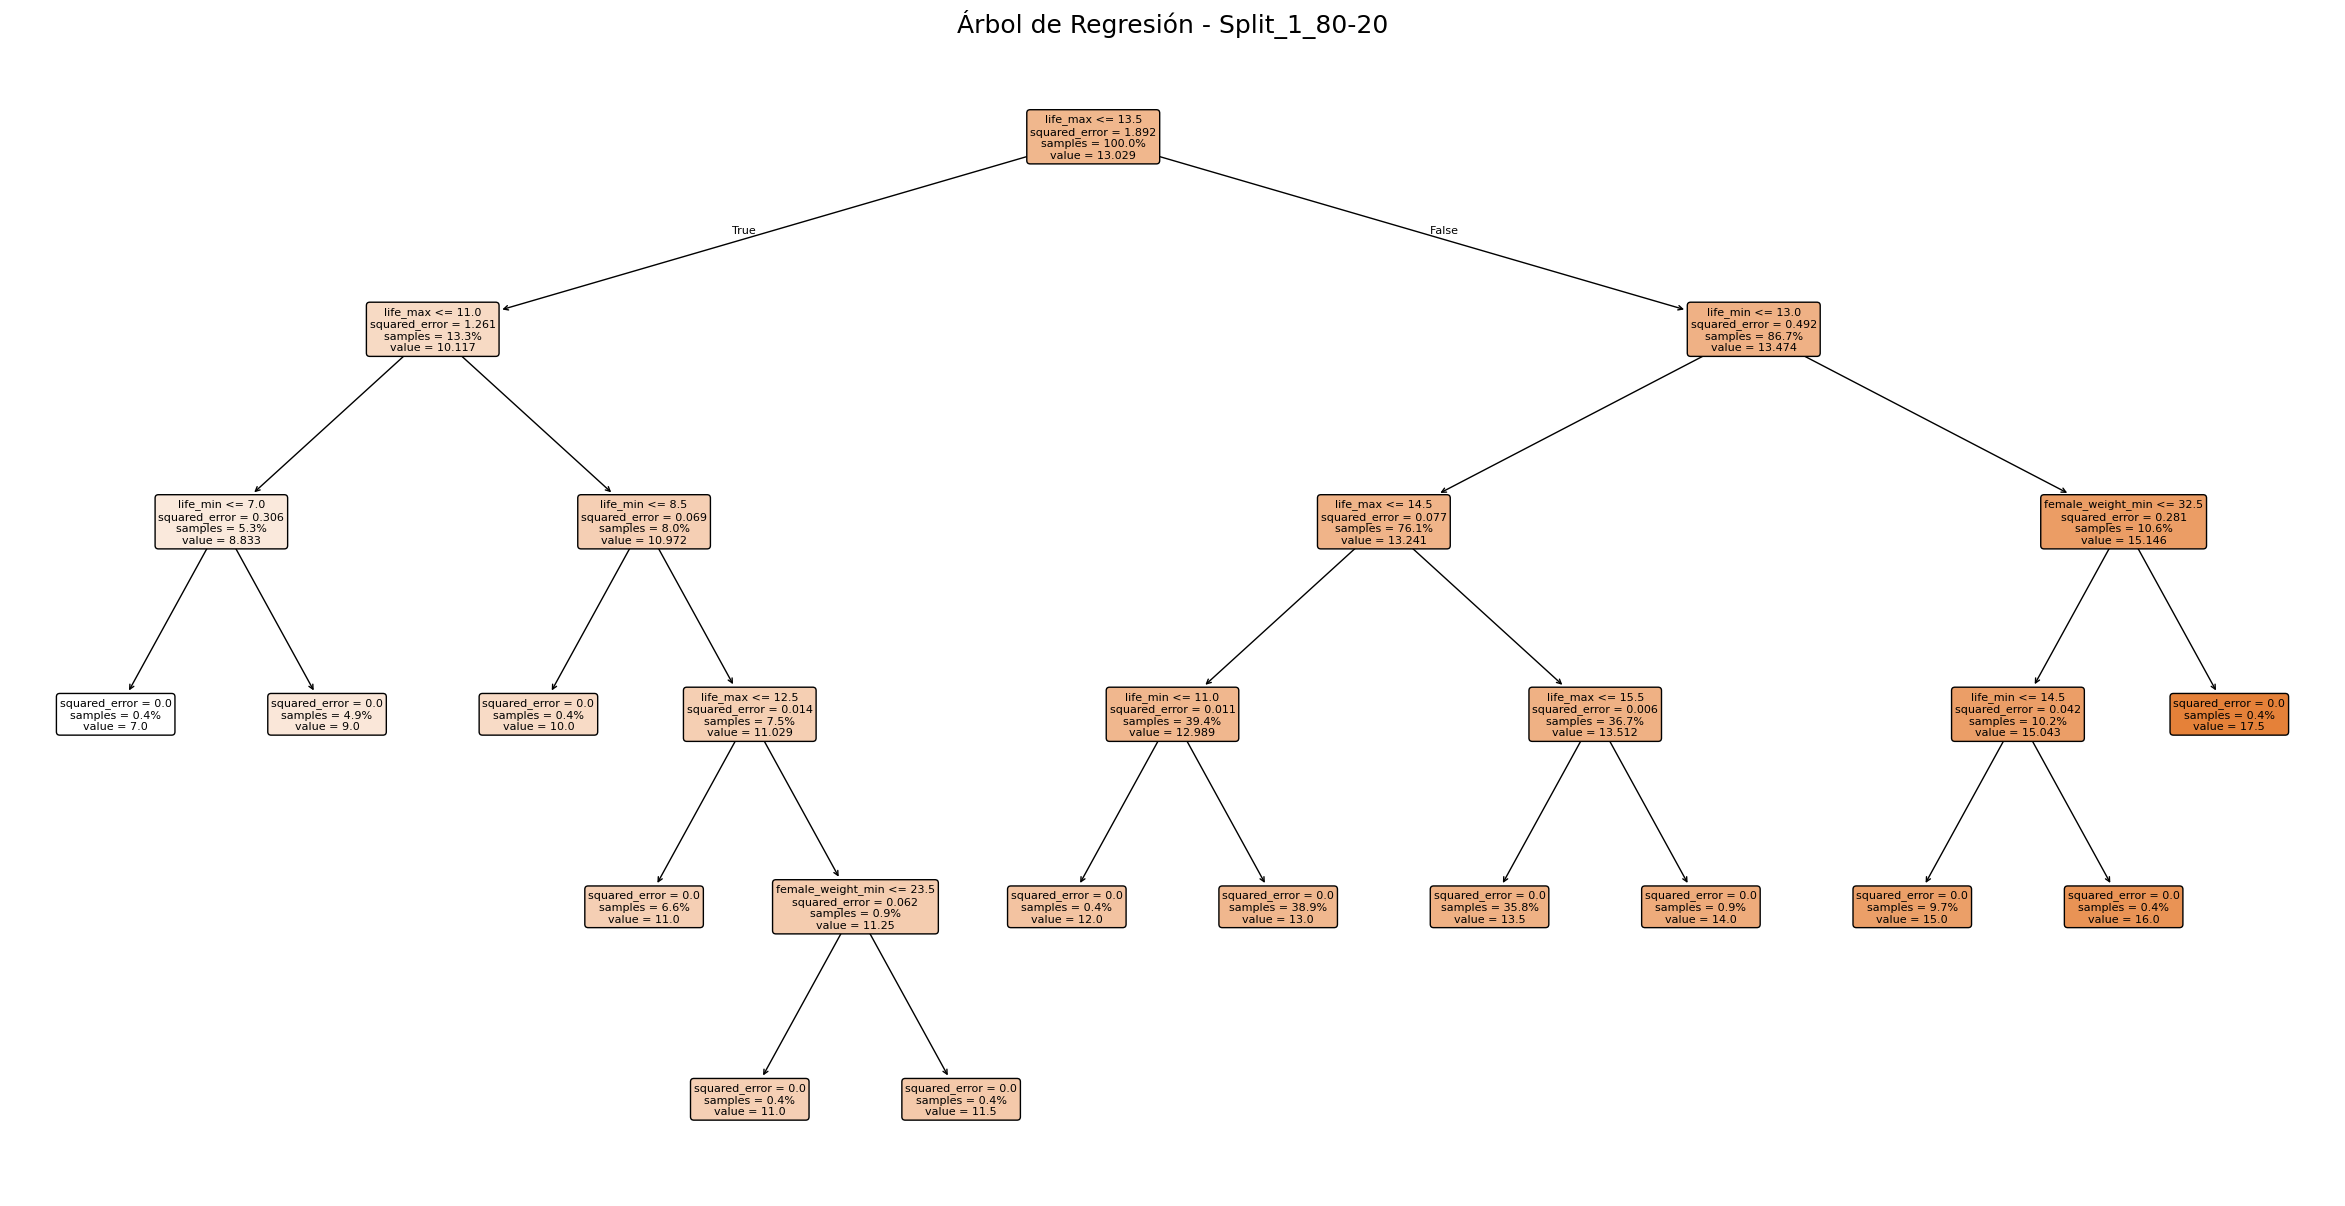


========== Split_2_70-30 ==========



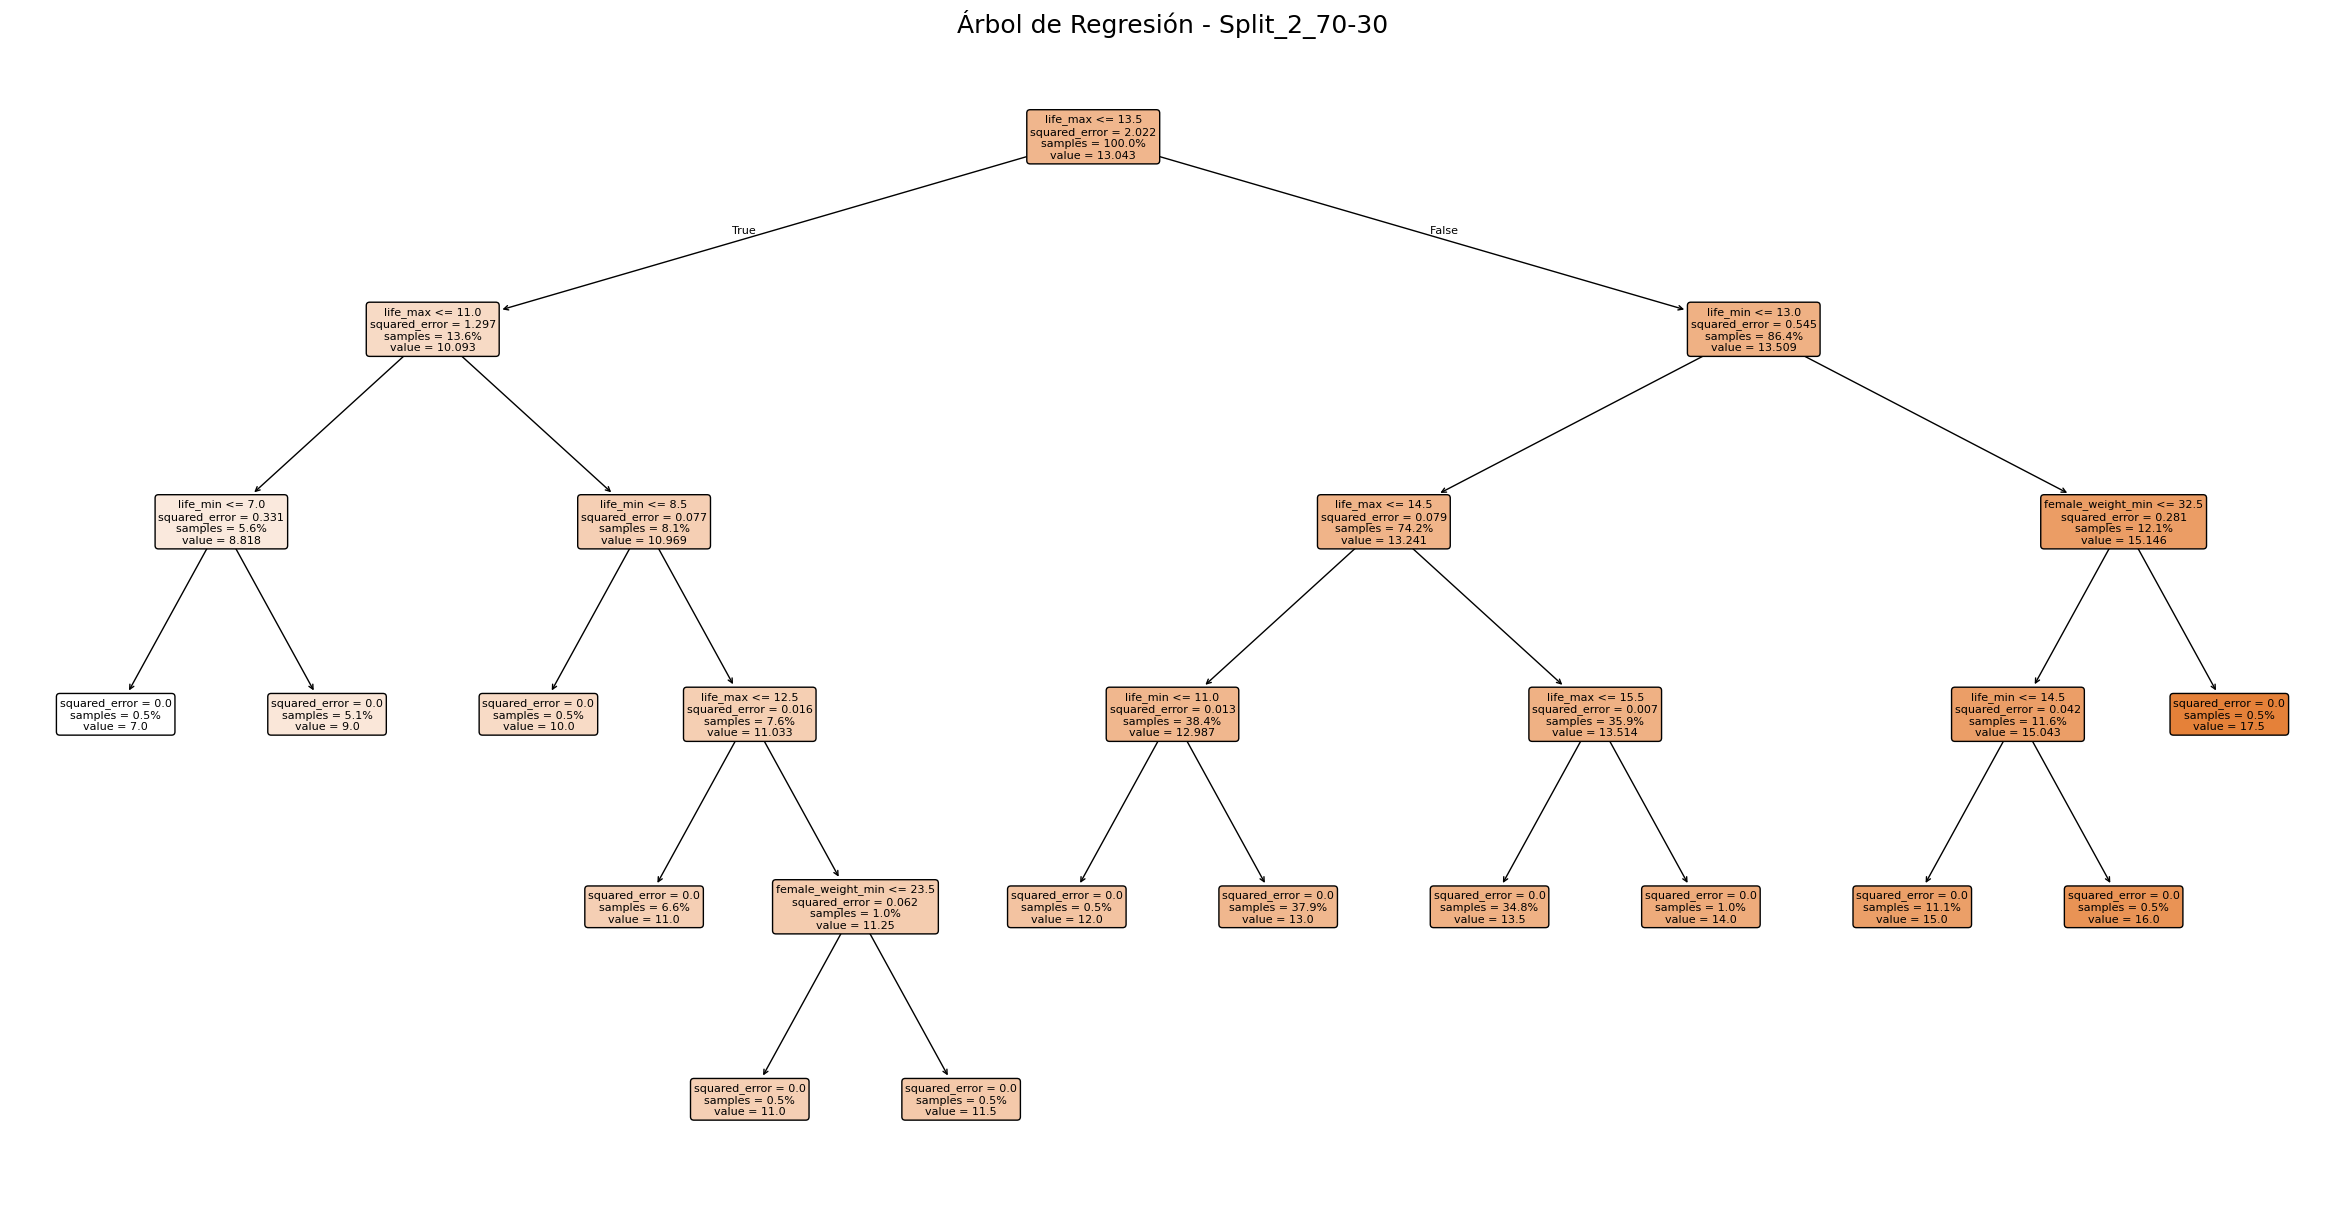


========== Split_3_60-40 ==========



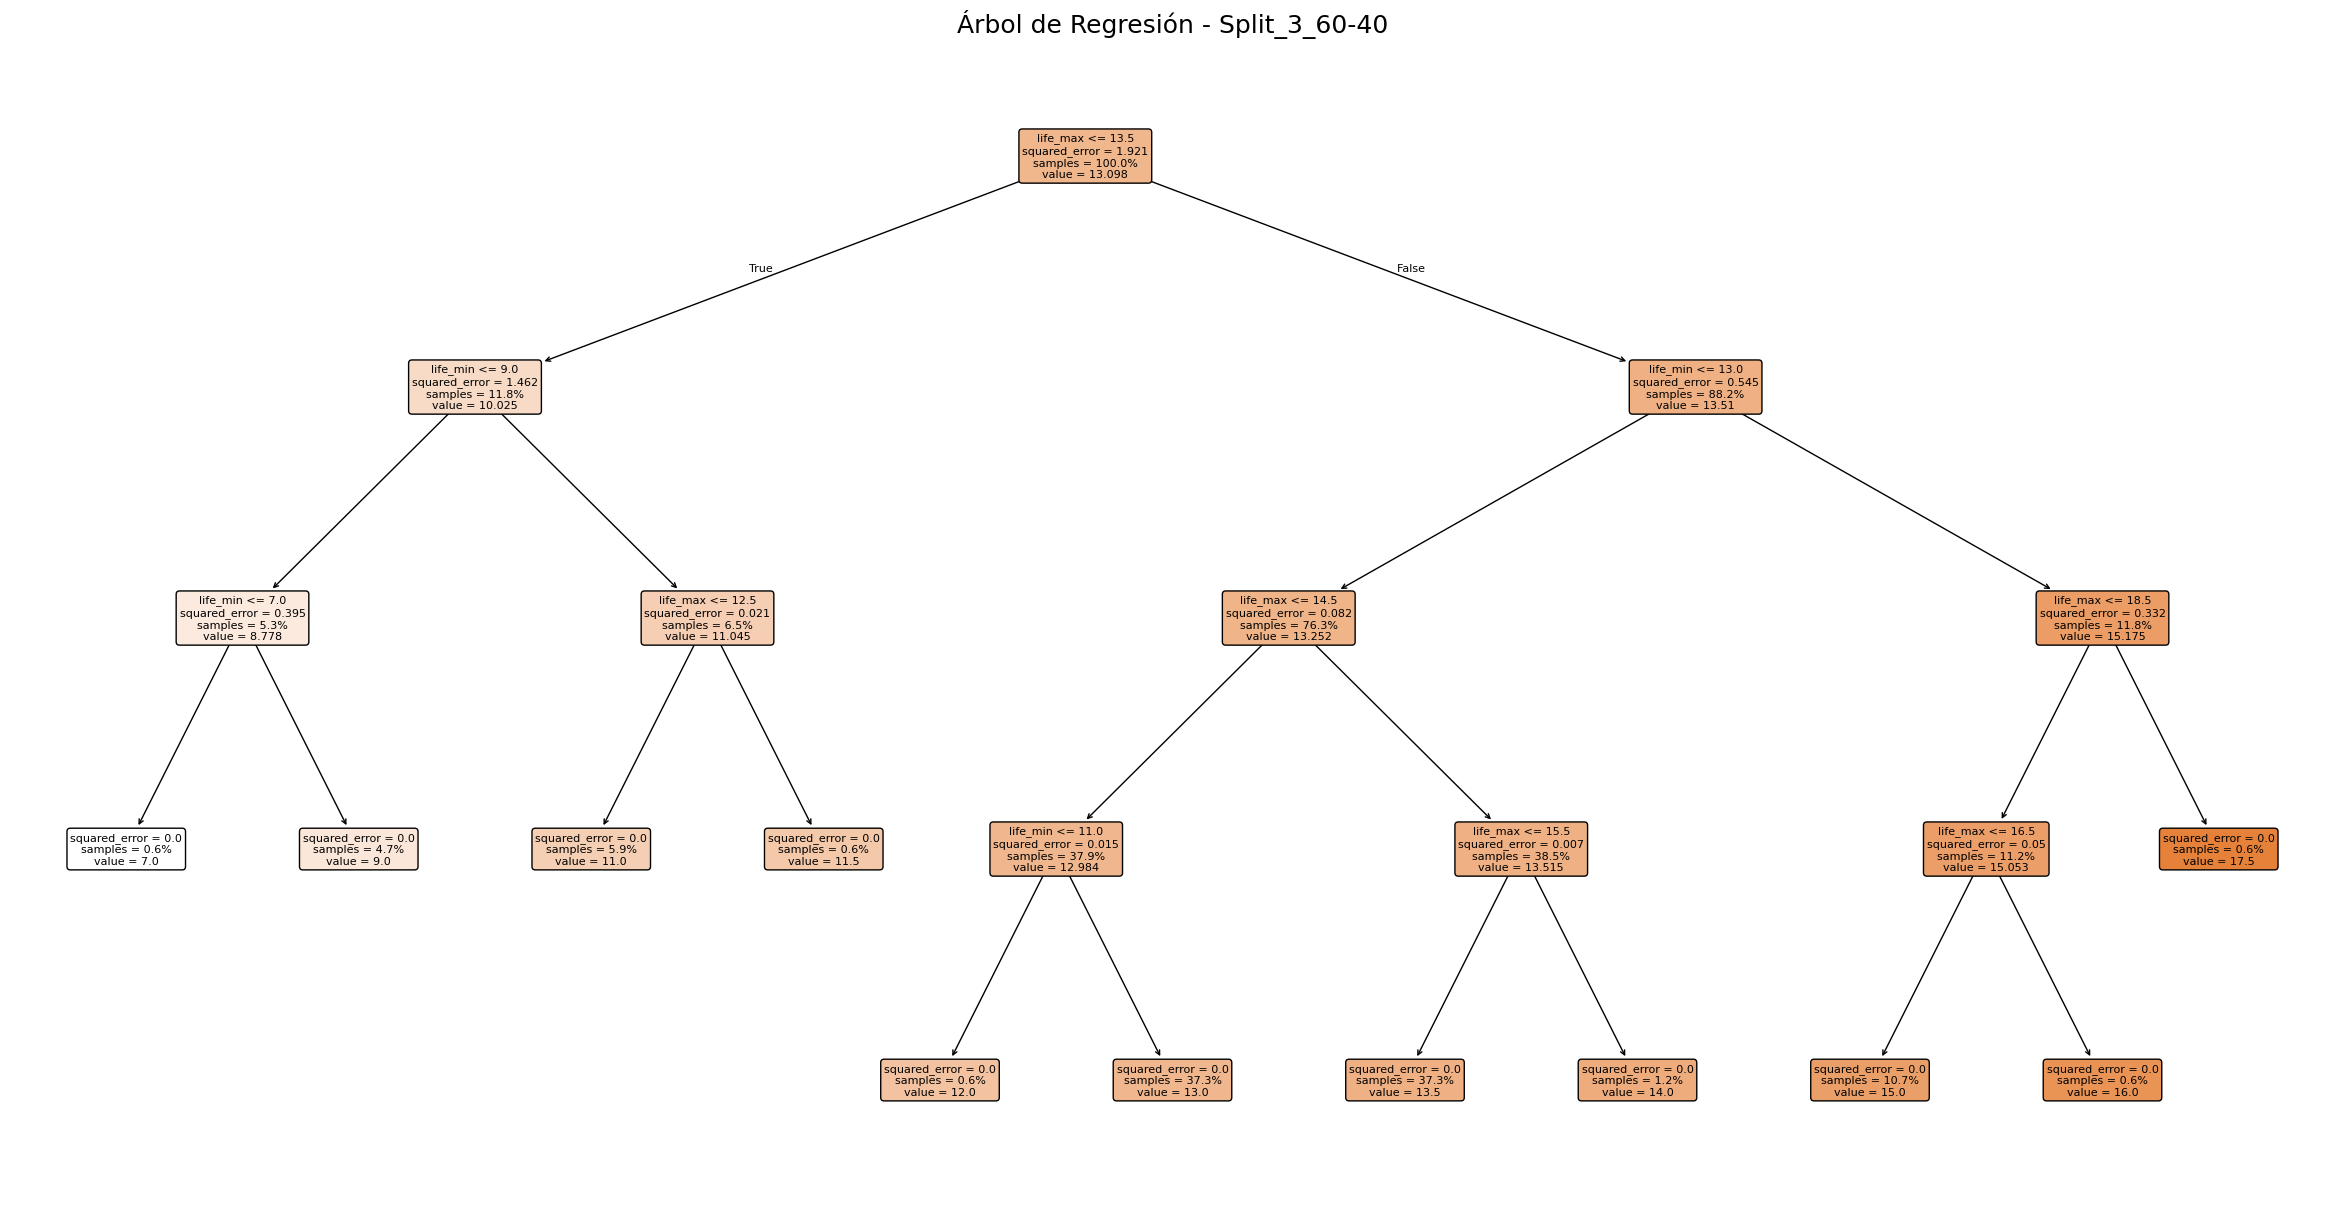

In [10]:
resultados = []

for nombre_split, test_size in splits.items():

    print(f"\n========== {nombre_split} ==========\n")

    # -----------------------------------
    # TRAIN TEST SPLIT
    # -----------------------------------

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=test_size,

        random_state=42
    )

    # -----------------------------------
    # MODELO
    # -----------------------------------

    modelo = DecisionTreeRegressor(

        random_state=42,

        max_depth=10,

        min_samples_split=2,

        min_samples_leaf=1
    )

    modelo.fit(
        X_train,
        y_train
    )

    # -----------------------------------
    # PREDICCIONES
    # -----------------------------------

    y_pred = modelo.predict(X_test)

    # -----------------------------------
    # MÉTRICAS
    # -----------------------------------

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    # -----------------------------------
    # RESULTADOS
    # -----------------------------------

    resultados.append({

        "split": nombre_split,

        "MAE": mae,

        "RMSE": rmse,

        "R2": r2
    })

    # -----------------------------------
    # ÁRBOL
    # -----------------------------------

    plt.figure(figsize=(30, 15))

    plot_tree(

        modelo,

        feature_names=X.columns,

        filled=True,

        rounded=True,

        fontsize=8,

        proportion=True
    )

    plt.title(

        f"Árbol de Regresión - {nombre_split}",

        fontsize=18
    )

    plt.savefig(

        f"data/graficas/arbol_regresion_{nombre_split}.png",

        bbox_inches='tight'
    )

    plt.show()

In [11]:
resultados_df = pd.DataFrame(
    resultados
)

resultados_df

,split,MAE,RMSE,R2
0,Split_1_80-20,0.052632,0.247797,0.976254
1,Split_2_70-30,0.035294,0.202920,0.979914
2,Split_3_60-40,0.039474,0.234146,0.974738


In [12]:
mejor_modelo = resultados_df.sort_values(
    by="R2",
    ascending=False
)

mejor_modelo

,split,MAE,RMSE,R2
1,Split_2_70-30,0.035294,0.202920,0.979914
0,Split_1_80-20,0.052632,0.247797,0.976254
2,Split_3_60-40,0.039474,0.234146,0.974738
